# 🎓 EWU Chatbot — Fine-tuning/Evaluation Pipeline
**Model:** `Qwen/Qwen2.5-7B-Instruct` + saved LoRA adapter (training skipped — resumed run)
**GPU:** T4 (Kaggle)
**Languages:** English · বাংলা · Banglish (≈5,000 pairs each, 15,000 total)
**Epochs:** 10
**Task:** EWU (East West University) student query chatbot

---
### Pipeline
1. Install dependencies
2. Load & inspect data (15k QA pairs, balanced by language)
3. Data distribution visualization
4. **Stratified 3-way split (train / val / test) + train↔test leakage audit**
5. Tokenizer + model setup (4-bit QLoRA)
6. **Zero-shot BASELINE evaluation** (before any fine-tuning) on a 333-test, category+difficulty-stratified set drawn from the verified ground-truth XLSX (§8.1) — independent of the JSONL train/val/test split
7. Training (10 epochs; multi-seed capable)
8. **Fine-tuned evaluation on the held-out TEST set** (not validation) — ROUGE, **chrF++**, BERTScore, domain-hit, etc. + bootstrap 95% CIs + per-language breakdown
9. **Statistical significance**: paired bootstrap + Wilcoxon signed-rank, baseline vs fine-tuned
10. **Qualitative error analysis** (worst cases, refusal rate)
10.1 **Human evaluation**: blank annotation sheets (correctness/helpfulness/fluency/faithfulness, 1–5) + Krippendorff's alpha for inter-annotator agreement
10.2 **LLM-as-judge** (optional, off by default): pairwise, position-bias-controlled comparison via an external LLM
11. Export fine-tuned adapter as ZIP
12. RAG — hybrid retrieval (BGE-M3 dense + BM25 sparse + BGE reranker) over KB + scraped website data
13. **Retrieval evaluation** (Recall@k / MRR / nDCG, weak/distant-supervision labels)
13.1 **RAGAS-lite**: local, free reimplementation of Faithfulness / Answer Relevancy / Context Precision / Context Recall
14. Semantic query cache + **threshold sweep benchmark** on a realistic (repeat/paraphrase/new) query stream
15. **Full ablation table**: Base vs Fine-tuned vs FT+RAG vs FT+RAG+Cache
15.1 **Correctness & multilingual-behaviour evaluation** (ported from `rasa-eval`): 0–4 judge → Strict/Acceptable accuracy + CIs, LaBSE semantic cosine, script-format checks, cross-language consistency, difficulty/category breakdowns, judge-vs-human validation
16. **Reproducibility appendix**: env, hyperparameters, seeds, **GPU-hours / energy estimate**, ACL/ARR-checklist-aligned fields + paper-ready CSV/JSON exports

> **What changed vs. the original notebook, and why it matters for a journal submission:**
> - Evaluation moved off the validation split (which was also used for early stopping) onto a genuinely
>   held-out **test** split, with an explicit **near-duplicate leakage check** between train and test.
> - Added a **zero-shot baseline** (same base model, no LoRA) so "the fine-tuned model scores X" becomes
>   "fine-tuning improved X over baseline by Δ, p < ...".
> - All headline metrics now ship with **95% bootstrap confidence intervals**, and baseline-vs-fine-tuned
>   deltas are tested for significance (paired bootstrap + Wilcoxon).
> - RAG retrieval quality and the semantic cache are now **benchmarked on their own terms**
>   (Recall@k/MRR/nDCG; hit-rate/precision/latency vs. similarity threshold), not just spot-checked.
> - Added **RAGAS-style Faithfulness/Answer-Relevancy/Context-Precision/Context-Recall** (Es et al. 2024;
>   ARES, Saad-Falcon et al. 2024 NAACL), locally reimplemented with an NLI model + embeddings so it costs
>   zero API calls, since surface-overlap metrics like ROUGE don't tell you if the model hallucinated.
> - Added **chrF++** (Popović 2015/2017), which handles Bangla's morphology and Banglish's mixed script
>   better than word-overlap metrics like BLEU/ROUGE.
> - Added a **human-evaluation rubric + Krippendorff's alpha**: a 2024 comparison of LLM fine-tuning
>   methods on a chatbot use case found automatic metrics (including RAGAS) didn't align with human
>   judgment and concluded human-in-the-loop evaluation is essential (Meyer et al. 2024, arXiv:2408.03562).
> - Added an **optional LLM-as-judge** pairwise comparison with position-bias control, following the
>   MT-Bench/Chatbot-Arena methodology (Zheng et al. 2023) — off by default, no API key required to run
>   the rest of the notebook.
> - An ablation table isolates the contribution of fine-tuning, RAG, and caching separately.
> - Added a **compute-budget / energy-estimate section** aligned with the ACL Rolling Review Responsible
>   NLP Research checklist (GPU-hours, parameter counts, hyperparameter-search disclosure).
> - Everything a methods/results section needs (tables, CSVs, env info) is written to
>   `/kaggle/working/paper_assets/`.
>
> **Honesty notes to carry into the paper's limitations section:** the retrieval "gold" labels and the
> RAGAS-lite context precision/recall are distant-supervision / lexical-overlap proxies, not
> human-annotated; RAGAS-lite is a free local reimplementation, not the official `ragas` package; the
> LLM-judge section needs your own API key and budget; multi-seed variance is off by default
> (`RANDOM_SEEDS = [42]`) because each extra seed re-runs the full 10-epoch training end to end; the
> energy/CO2 estimate is TDP-based, not measured with a power meter.


## 1 · Install Dependencies

In [1]:
%%capture
# ── STEP 1: set LD_LIBRARY_PATH before any CUDA lib is touched ───────────────
import os, subprocess, sys

cuda_lib = "/usr/local/cuda/lib64"
ld = os.environ.get("LD_LIBRARY_PATH", "")
if cuda_lib not in ld:
    os.environ["LD_LIBRARY_PATH"] = f"{cuda_lib}:{ld}"

# ── STEP 2: install pinned stack for Kaggle T4 (CUDA 12.x, Python 3.12) ──────
# Root issue: torchvision uses torch.library.register_fake (added in torch 2.1).
# We must pin torch + torchvision together FIRST, then install the rest.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "torch==2.3.1",                          # register_fake available; CUDA 12 wheel
    "torchvision==0.18.1",                   # built against torch 2.3.1
    "--extra-index-url", "https://download.pytorch.org/whl/cu121",
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "pandas==2.2.2",
    "seaborn==0.13.2",
    "scipy==1.13.1",
    "matplotlib==3.8.4",
    "triton==2.3.1",            # provides triton.ops; must precede bitsandbytes
    "bitsandbytes==0.44.1",     # CUDA-12 backend; no triton.ops import issue
    "transformers==4.46.3",
    "peft==0.13.2",
    "trl==0.11.4",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "sentencepiece",
    "rouge-score",
    "bert-score",
    "sacrebleu",            # chrF++ — standard MT/NLG metric, more reliable than BLEU/ROUGE for
                            # morphologically rich languages like Bangla (Popovic 2015/2017)
    "rapidfuzz",            # fast fuzzy matching: leakage audit + weak retrieval labels
    "beautifulsoup4",       # strip HTML from scraped website pages for the RAG KB
    "krippendorff",         # inter-annotator agreement for the human-evaluation section
    "tqdm",
])

print("✅ All packages installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 315.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 330.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 218.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 361.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 239.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 236.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 204.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 241.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 228.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 227.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 273.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 224.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.3.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 168.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 286.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 134.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 226.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 280.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 292.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 312.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.3.1+cu121 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.8.4 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but

In [2]:
# ── CUDA / bitsandbytes sanity check ─────────────────────────────────────────
import os, glob, sys

# 1. Keep LD_LIBRARY_PATH pointing at CUDA 12 libs
cuda_lib = "/usr/local/cuda/lib64"
ld = os.environ.get("LD_LIBRARY_PATH", "")
if cuda_lib not in ld:
    os.environ["LD_LIBRARY_PATH"] = f"{cuda_lib}:{ld}"

# 2. Symlink libnvJitLink.so.12 if only the unversioned .so exists
#    (bitsandbytes 0.44.x looks for the .12 variant on some images)
for pattern in ["/usr/local/cuda/lib64/libnvJitLink*.so*",
                "/usr/lib/x86_64-linux-gnu/libnvJitLink*.so*"]:
    for found in glob.glob(pattern):
        versioned = os.path.join(os.path.dirname(found), "libnvJitLink.so.12")
        if not os.path.exists(versioned):
            try:
                os.symlink(found, versioned)
                print(f"  Symlink created: {versioned} → {found}")
            except PermissionError:
                pass   # read-only FS on some Kaggle images; bnb 0.44.1 doesn't need it

# 3. Validate bitsandbytes import
try:
    import bitsandbytes as bnb
    print(f"✅ bitsandbytes {bnb.__version__} loaded OK")
except Exception as e:
    print(f"❌ bitsandbytes load error: {e}")
    raise

# 4. Validate triton
try:
    import triton
    print(f"✅ triton {triton.__version__} loaded OK")
except Exception as e:
    print(f"⚠️  triton not available: {e} (non-fatal if peft/trl don't need it)")

import torch
print(f"✅ torch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")


✅ bitsandbytes 0.44.1 loaded OK
✅ triton 2.3.1 loaded OK
✅ torch 2.3.1+cu121  |  CUDA available: True


## 2 · Imports & Config

In [3]:
import os, json, glob, random, math, re, zipfile, shutil, warnings, time, platform, copy
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from tqdm.auto import tqdm

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    TrainerCallback,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM
from datasets import Dataset

from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import sacrebleu
from rapidfuzz import process, fuzz as rf_fuzz
from scipy.stats import wilcoxon
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIRS  = [                                                                # ← list every dataset folder to train on
    "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs"
]
KB_DIR       = "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs/KB/KB"      # ← EDIT: RAG-optimized markdown KB (if you have one)
GROUND_TRUTH_XLSX = "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs/University_Chatbot_Questions_1110_GROUND_TRUTHS_VERIFIED.xlsx"  # ← EDIT
OUTPUT_DIR   = "/kaggle/working/ewu_qwen_lora"
ZIP_NAME     = "/kaggle/working/ewu_chatbot_finetuned.zip"
PAPER_ASSETS_DIR = "/kaggle/working/paper_assets"       # ← everything the paper's tables/figures need lands here
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PAPER_ASSETS_DIR, exist_ok=True)

# ── Model / training ──────────────────────────────────────────────────────────
MODEL_ID    = "Qwen/Qwen2.5-7B-Instruct"
NUM_EPOCHS  = 10
MAX_SEQ_LEN = 512          # safe for T4 16 GB with 4-bit
BATCH_SIZE  = 2            # per-device; grad_accum=8 → effective 16
GRAD_ACCUM  = 8
LR          = 2e-4

# ── Research-grade evaluation config ──────────────────────────────────────────
TEST_FRACTION_OF_TOTAL = 0.10   # held-out test split, NEVER used for training or early stopping
VAL_FRACTION_OF_TOTAL  = 0.10   # used only for early stopping during training
LEAKAGE_SIM_THRESHOLD  = 90     # rapidfuzz token_sort_ratio (0-100); train/test prompts above this are flagged
QUESTIONS_PER_DIFFICULTY = 1     # eval set is now drawn from the verified ground-truth XLSX, NOT from
                                 # the JSONL train/val/test split above. 1 question per (Category × Difficulty)
                                 # → 3/category (Easy+Medium+Hard) × 37 categories × 3 languages = 333 tests.
                                 # This eval set is independent of train_idx/val_idx/test_idx — it exists
                                 # purely to score the model, and is never used for training or leakage-checked
                                 # against the training corpus (different source data entirely).
N_BOOTSTRAP  = 1000              # bootstrap resamples for confidence intervals / significance tests
BOOTSTRAP_CI = 0.95
RANDOM_SEEDS = [42]              # add e.g. [42, 123, 2024] for multi-seed variance — COSTLY: each extra
                                  # seed re-runs the full NUM_EPOCHS training end-to-end
WEAK_LABEL_THRESHOLD  = 60       # rapidfuzz token_set_ratio for reference↔chunk distant-supervision matching
CACHE_THRESHOLD_SWEEP = [0.85, 0.90, 0.92, 0.95, 0.97]
CHUNK_SIZE, CHUNK_OVERLAP = 500, 80
TOP_K_DENSE, TOP_K_SPARSE, TOP_K_FINAL = 10, 10, 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 3 · Data Loading

In [4]:
# -- JSON/JSONL discovery across multiple dataset folders, with dedup --------
# Reads every *.jsonl AND *.json under each folder in DATA_DIRS (JSON files may
# be either a single JSON array of records or newline-delimited JSON), then
# drops exact-duplicate (prompt, response) pairs -- keeping the first
# occurrence -- so overlap between folders (e.g. the same pair present in both
# an English-only set and a combined multilingual set) is only counted once.
all_paths = []
for d in DATA_DIRS:
    for ext in ("*.jsonl", "*.json"):
        all_paths += glob.glob(os.path.join(d, ext))
        all_paths += glob.glob(os.path.join(d, "**", ext), recursive=True)

seen, data_files = set(), []
for p in sorted(all_paths):
    rp = os.path.realpath(p)
    if rp not in seen:
        seen.add(rp)
        data_files.append(p)
data_files = sorted(data_files)
print(f"Found {len(data_files)} unique JSON/JSONL file(s) across {len(DATA_DIRS)} folder(s)\n")

def _norm(text: str) -> str:
    # Normalize for dedup / fuzzy-match comparison: strip, lowercase, collapse whitespace.
    return " ".join(text.strip().lower().split())

def _extract_pair(ex: dict):
    p = (ex.get("prompt") or ex.get("instruction") or ex.get("input", "")).strip()
    r = (ex.get("response") or ex.get("output") or ex.get("answer", "")).strip()
    return p, r

def _iter_records(fname: str):
    # Yield dict records from a file that may be JSON-lines OR a single JSON
    # document (a list of records, or a dict wrapping a list under a common
    # key like "data"/"pairs"/"qa"/"examples"). Returns (records, parse_errors).
    with open(fname, encoding="utf-8") as f:
        raw = f.read()

    stripped = raw.strip()
    if not stripped:
        return [], 0

    # Try whole-file JSON first (array or dict-of-array) -- typical for *.json exports.
    try:
        obj = json.loads(stripped)
        if isinstance(obj, list):
            return obj, 0
        if isinstance(obj, dict):
            for key in ("data", "pairs", "qa", "examples", "items", "records"):
                if isinstance(obj.get(key), list):
                    return obj[key], 0
            # Single record as a top-level dict.
            return [obj], 0
    except json.JSONDecodeError:
        pass  # fall through to line-by-line JSONL parsing

    # JSONL: one JSON object per line.
    records, errors = [], 0
    for line in stripped.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            errors += 1
    return records, errors

_common_root = os.path.commonpath(DATA_DIRS) if len(DATA_DIRS) > 1 else DATA_DIRS[0]

inputs, outputs, file_tags = [], [], []
file_stats = {}
seen_pairs = set()      # (normalized_prompt, normalized_response) already kept
total_dupes_dropped = 0

for fname in data_files:
    tag = os.path.relpath(fname, _common_root)
    count, dupes_here = 0, 0
    try:
        records, errors = _iter_records(fname)
    except Exception as e:
        records, errors = [], -1
        print(f"  [ERROR]  {tag:<60s}  failed to read: {e}")

    for ex in records:
        if not isinstance(ex, dict):
            continue
        p, r = _extract_pair(ex)
        if not p or not r:
            continue
        key = (_norm(p), _norm(r))
        if key in seen_pairs:
            dupes_here += 1
            total_dupes_dropped += 1
            continue
        seen_pairs.add(key)
        inputs.append(p)
        outputs.append(r)
        file_tags.append(tag)
        count += 1

    file_stats[tag] = {"pairs": count, "errors": errors, "dupes_dropped": dupes_here}
    status = "OK   " if errors == 0 else ("WARN " if errors > 0 else "ERR  ")
    flag = "  <!> 0 pairs loaded -- check keys/format!" if count == 0 else ""
    print(f"  [{status}]  {tag:<60s}  {count:>4d} pairs  |  {dupes_here:>4d} dupes skipped  |  {errors} JSON errors{flag}")

print(f"\n{'-'*70}")
print(f"  TOTAL: {len(inputs)} unique Q&A pairs loaded  |  {total_dupes_dropped} exact duplicates dropped")
print(f"{'-'*70}")

if len(inputs) == 0:
    raise ValueError("No data loaded -- check DATA_DIRS paths or file format!")

Found 181 unique JSON/JSONL file(s) across 1 folder(s)

  [OK   ]  KB/KB/academic_council.json                                      0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/admission_deadlines.json                                   0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_admission_process.json                             0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_admission_requirements.json                        0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_events_workshops.json                              0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_facilites.json                                     0 pairs  |     0 dupes skipped  |

## 4 · Data Distribution & Visualisation

In [5]:
# ── Language labels from folder (trusted structure) ──────────────────────────
# DATA_DIRS now contains subfolders: english/, bangla/, banglish/
# file_tags are paths relative to the common root, so the language is just
# the first path component.

def folder_implied_language(tag: str) -> str:
    parts = os.path.normpath(tag).split(os.sep)
    top = parts[0].lower() if parts else ""
    if top in ("bangla", "banglish", "english"):
        return top
    return "english"  # fallback for anything not in a language subfolder

languages = [folder_implied_language(tag) for tag in file_tags]
lang_counts = Counter(languages)

input_lens  = [len(q.split()) for q in inputs]
output_lens = [len(r.split()) for r in outputs]

print("Language distribution (by folder):")
for lang, cnt in sorted(lang_counts.items(), key=lambda x: -x[1]):
    print(f"  {lang:<12}: {cnt:>5d}  ({cnt/len(inputs)*100:.1f}%)")
print(f"\nAvg question length : {np.mean(input_lens):.1f} words")
print(f"Avg answer length   : {np.mean(output_lens):.1f} words")
print("\nExpected ~5,000 pairs per language (English / Bangla / Banglish) per the dataset description —")
print("compare against the counts above.")

Language distribution (by folder):
  english     :  5130  (47.2%)
  bangla      :  2954  (27.2%)
  banglish    :  2793  (25.7%)

Avg question length : 11.2 words
Avg answer length   : 31.6 words

Expected ~5,000 pairs per language (English / Bangla / Banglish) per the dataset description —
compare against the counts above.


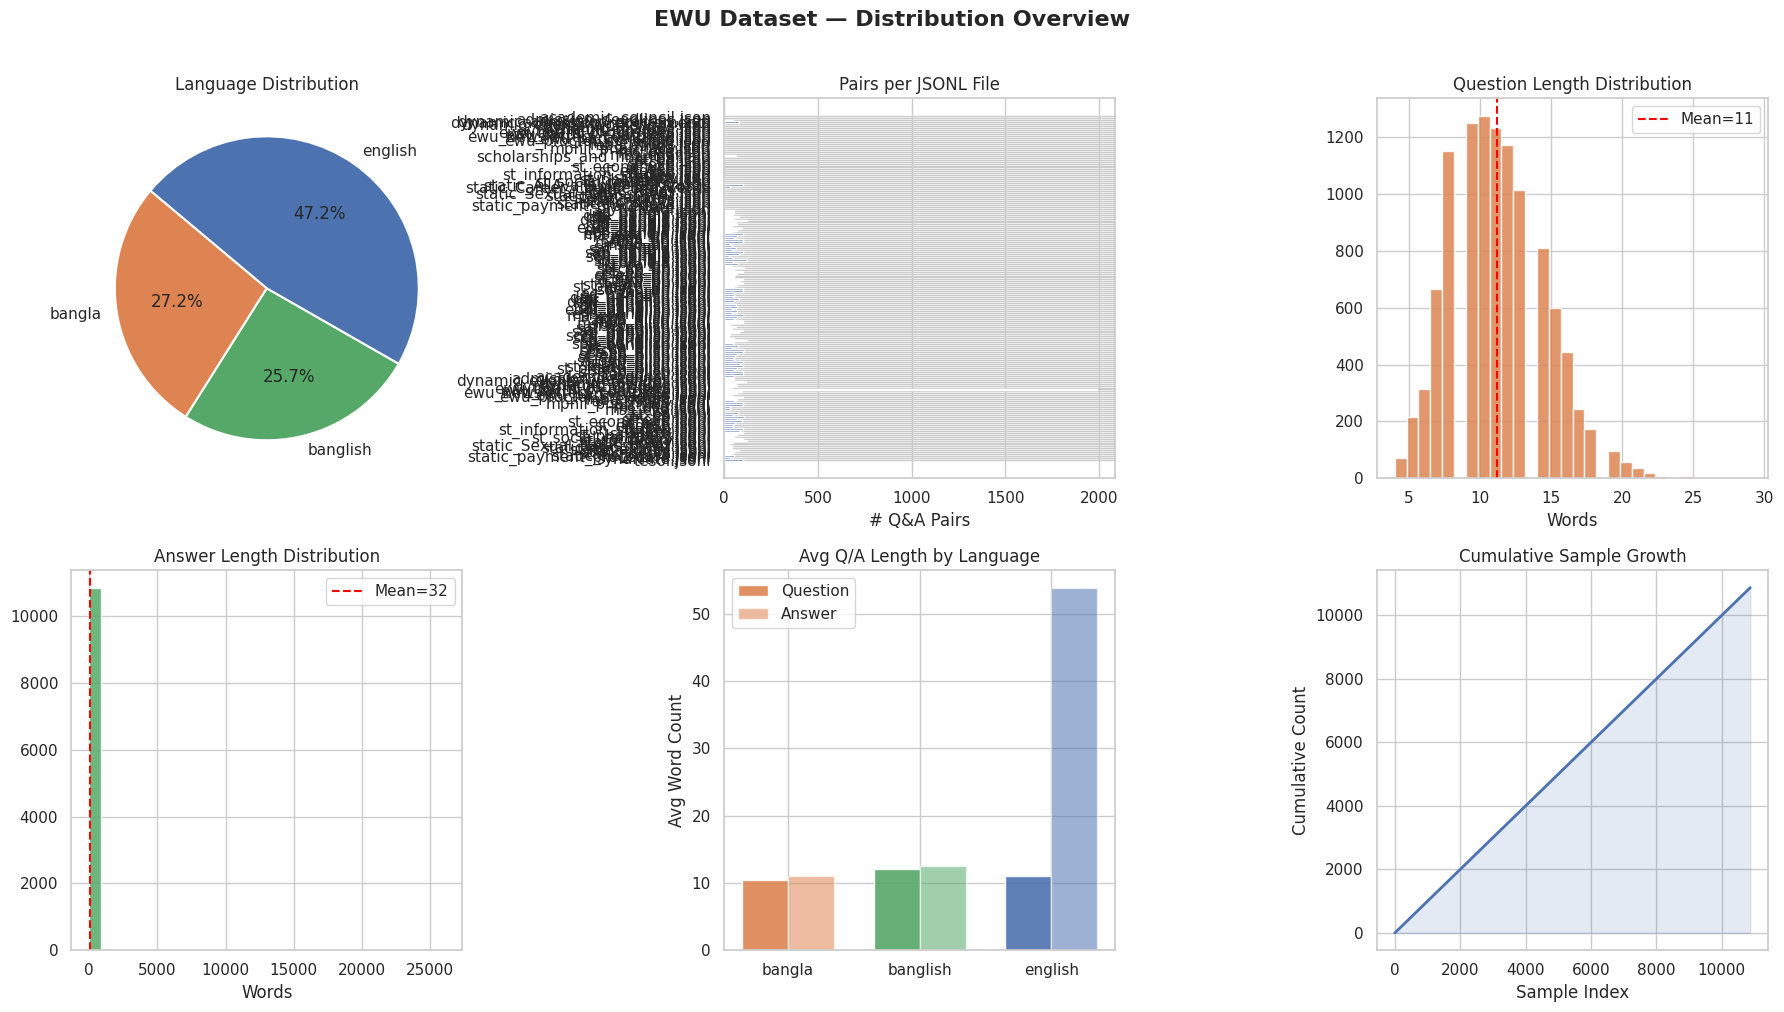

📊 Distribution plots saved to paper_assets/.


In [6]:
# ── Plots ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EWU Dataset — Distribution Overview', fontsize=16, fontweight='bold', y=1.01)

COLORS = {'english': '#4C72B0', 'bangla': '#DD8452', 'banglish': '#55A868'}

# 1. Language pie
ax = axes[0, 0]
labels = list(lang_counts.keys())
sizes  = [lang_counts[l] for l in labels]
clrs   = [COLORS.get(l, '#aaa') for l in labels]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=clrs,
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Language Distribution')

# 2. Pairs per file
ax = axes[0, 1]
tags_short = [t.split('/')[-1][:30] for t in file_stats.keys()]
pair_cnts  = [v['pairs'] for v in file_stats.values()]
ax.barh(tags_short, pair_cnts, color='#4C72B0', edgecolor='white')
ax.set_xlabel('# Q&A Pairs')
ax.set_title('Pairs per JSONL File')
ax.invert_yaxis()

# 3. Question length histogram
ax = axes[0, 2]
ax.hist(input_lens, bins=30, color='#DD8452', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(input_lens), color='red', linestyle='--', label=f'Mean={np.mean(input_lens):.0f}')
ax.set_xlabel('Words')
ax.set_title('Question Length Distribution')
ax.legend()

# 4. Answer length histogram
ax = axes[1, 0]
ax.hist(output_lens, bins=30, color='#55A868', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(output_lens), color='red', linestyle='--', label=f'Mean={np.mean(output_lens):.0f}')
ax.set_xlabel('Words')
ax.set_title('Answer Length Distribution')
ax.legend()

# 5. Stacked bar — Q & A lengths by language
ax = axes[1, 1]
lang_q_lens = {l: [] for l in lang_counts}
lang_a_lens = {l: [] for l in lang_counts}
for q, r, l in zip(inputs, outputs, languages):
    lang_q_lens[l].append(len(q.split()))
    lang_a_lens[l].append(len(r.split()))
x = np.arange(len(lang_counts))
w = 0.35
ax.bar(x - w/2, [np.mean(lang_q_lens[l]) for l in lang_counts], w,
       color=[COLORS.get(l,'#aaa') for l in lang_counts], alpha=0.9, label='Question')
ax.bar(x + w/2, [np.mean(lang_a_lens[l]) for l in lang_counts], w,
       color=[COLORS.get(l,'#aaa') for l in lang_counts], alpha=0.55, label='Answer')
ax.set_xticks(x)
ax.set_xticklabels(list(lang_counts.keys()))
ax.set_ylabel('Avg Word Count')
ax.set_title('Avg Q/A Length by Language')
ax.legend()

# 6. Cumulative sample count
ax = axes[1, 2]
ax.plot(np.cumsum([1]*len(inputs)), color='#4C72B0', linewidth=2)
ax.fill_between(range(len(inputs)), np.cumsum([1]*len(inputs)), alpha=0.15, color='#4C72B0')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cumulative Count')
ax.set_title('Cumulative Sample Growth')

plt.tight_layout()
plt.savefig(os.path.join(PAPER_ASSETS_DIR, 'fig_data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('📊 Distribution plots saved to paper_assets/.')


## 4.1 · Language-Label Spot-Check

Language labels now come from the dataset's folder structure (`bangla/`, `banglish/`, `english/`), not text-content detection — trusted, since the folders were curated by hand.

This cell still samples a small stratified set per label for manual review, as a lightweight check that files ended up filed under the correct folder (e.g. an accidental Banglish file left under `english/`) before treating the per-language splits as ground truth downstream.


In [7]:
N_LANGID_SPOTCHECK_PER_LANG = 15
rng_lid = random.Random(SEED)

langid_rows = []
_lang_buckets = {}
for i, lang in enumerate(languages):
    _lang_buckets.setdefault(lang, []).append(i)

for lang, idxs in _lang_buckets.items():
    sample_idxs = rng_lid.sample(idxs, min(N_LANGID_SPOTCHECK_PER_LANG, len(idxs)))
    for i in sample_idxs:
        langid_rows.append({
            "index": i,
            "question": inputs[i],
            "predicted_language": lang,
            "is_correct_1_or_0": "",     # ← fill in by hand: 1 if predicted_language is right, else 0
            "true_language_if_wrong": "",  # ← fill in only if is_correct_1_or_0 == 0
        })

langid_df = pd.DataFrame(langid_rows)
langid_path = os.path.join(PAPER_ASSETS_DIR, "language_detection_spotcheck_BLANK.csv")
langid_df.to_csv(langid_path, index=False)
print(f"Blank spot-check sheet written: {langid_path}  ({len(langid_df)} items, "
      f"{N_LANGID_SPOTCHECK_PER_LANG} per detected language)")
print("Fill in is_correct_1_or_0 by hand, save as ..._FILLED.csv in the same folder, then run the next cell.")


Blank spot-check sheet written: /kaggle/working/paper_assets/language_detection_spotcheck_BLANK.csv  (45 items, 15 per detected language)
Fill in is_correct_1_or_0 by hand, save as ..._FILLED.csv in the same folder, then run the next cell.


In [8]:
filled_langid_path = os.path.join(PAPER_ASSETS_DIR, "language_detection_spotcheck_FILLED.csv")

if not os.path.exists(filled_langid_path):
    print(f"{filled_langid_path} not found yet — this cell is a no-op until the spot-check sheet above "
          f"is manually filled in and saved with the _FILLED suffix.")
else:
    filled = pd.read_csv(filled_langid_path)
    filled["is_correct_1_or_0"] = filled["is_correct_1_or_0"].astype(int)
    overall_acc = filled["is_correct_1_or_0"].mean()
    print(f"Overall language-label accuracy on the spot-check sample: {overall_acc*100:.1f}% "
          f"(n={len(filled)})")
    print("\nBy predicted language:")
    for lang, grp in filled.groupby("predicted_language"):
        acc = grp["is_correct_1_or_0"].mean()
        print(f"  {lang:<10}: {acc*100:>5.1f}%  (n={len(grp)})")

    misclassified = filled[filled["is_correct_1_or_0"] == 0]
    if len(misclassified) > 0:
        print(f"\n{len(misclassified)} misclassification(s) found — report this rate in the paper's data")
        print("section as a known limitation of the Unicode-heuristic language detector, e.g.:")
        print(f'  "Manual review of {len(filled)} randomly sampled items found the language-detection')
        print(f'   heuristic to be {overall_acc*100:.1f}% accurate, with errors concentrated in "')
        print( "   {predicted language(s) with lowest accuracy}.\"")
        misclassified.to_csv(os.path.join(PAPER_ASSETS_DIR, "language_detection_misclassified.csv"), index=False)


/kaggle/working/paper_assets/language_detection_spotcheck_FILLED.csv not found yet — this cell is a no-op until the spot-check sheet above is manually filled in and saved with the _FILLED suffix.


## 5 · Stratified Train / Val / Test Split + Leakage Audit
The original pipeline split data into train/val only and then evaluated on the validation set — the same
set used for early stopping. That is data leakage for reporting purposes: the checkpoint you keep is the
one the validation set already liked best, so validation-set metrics overstate real generalization.

Here we carve out a **third, genuinely held-out test split** (stratified by language) that the model never
sees during training or model selection, and audit it for **near-duplicate leakage** from the training set
using fuzzy string matching (typo/paraphrase-tolerant, unlike exact-match dedup).

In [9]:
# ── 3-way stratified split (by language) ──────────────────────────────────────
random.seed(SEED)

lang_to_indices = {}
for i, lang in enumerate(languages):
    lang_to_indices.setdefault(lang, []).append(i)

train_idx, val_idx, test_idx = [], [], []
for lang, idxs in lang_to_indices.items():
    idxs = idxs[:]
    random.shuffle(idxs)
    n = len(idxs)
    n_test = max(1, int(round(TEST_FRACTION_OF_TOTAL * n)))
    n_val  = max(1, int(round(VAL_FRACTION_OF_TOTAL * n)))
    test_idx.extend(idxs[:n_test])
    val_idx.extend(idxs[n_test:n_test + n_val])
    train_idx.extend(idxs[n_test + n_val:])

random.shuffle(train_idx); random.shuffle(val_idx); random.shuffle(test_idx)

print(f"Train: {len(train_idx)}   Val: {len(val_idx)}   Test: {len(test_idx)}\n")
print("Per-language breakdown:")
for lang in lang_to_indices:
    tr = sum(1 for i in train_idx if languages[i] == lang)
    va = sum(1 for i in val_idx if languages[i] == lang)
    te = sum(1 for i in test_idx if languages[i] == lang)
    print(f"  {lang:<10}: train={tr:>5d}   val={va:>4d}   test={te:>4d}")

# ── Leakage audit: near-duplicate prompts between TRAIN and TEST ──────────────
# A model can look deceptively good on test purely by having memorized a near-
# identical training prompt. We fuzzy-match every test prompt against every
# train prompt (token_sort_ratio, robust to word order / minor edits) and flag
# pairs above LEAKAGE_SIM_THRESHOLD. rapidfuzz's C implementation makes the
# O(|test| x |train|) comparison tractable (a couple of minutes on CPU here).
train_prompts_norm = [_norm(inputs[i]) for i in train_idx]
leaked_test_idx = []
for ti in tqdm(test_idx, desc="Leakage scan (test vs train)"):
    q = _norm(inputs[ti])
    match = process.extractOne(q, train_prompts_norm, scorer=rf_fuzz.token_sort_ratio)
    if match is not None and match[1] >= LEAKAGE_SIM_THRESHOLD:
        leaked_test_idx.append((ti, match[1]))

print(f"\n⚠️  {len(leaked_test_idx)} / {len(test_idx)} test prompts "
      f"({len(leaked_test_idx)/max(len(test_idx),1)*100:.1f}%) are near-duplicates "
      f"(similarity ≥ {LEAKAGE_SIM_THRESHOLD}) of a training prompt.")

if leaked_test_idx:
    leaked_set = {i for i, _ in leaked_test_idx}
    test_idx = [i for i in test_idx if i not in leaked_set]
    print(f"   → Removed from TEST set. Clean, leakage-audited test size: {len(test_idx)}")
    print("   Report this leakage rate in the paper's data / limitations section.")
else:
    print("   → No leakage detected at this threshold; test set kept as-is.")

with open(os.path.join(PAPER_ASSETS_DIR, "split_and_leakage_summary.json"), "w") as f:
    json.dump({
        "train_size": len(train_idx), "val_size": len(val_idx), "test_size": len(test_idx),
        "leaked_removed": len(leaked_test_idx), "leakage_threshold": LEAKAGE_SIM_THRESHOLD,
    }, f, indent=2)


Train: 8703   Val: 1087   Test: 1087

Per-language breakdown:
  bangla    : train= 2364   val= 295   test= 295
  banglish  : train= 2235   val= 279   test= 279
  english   : train= 4104   val= 513   test= 513


Leakage scan (test vs train):   0%|          | 0/1087 [00:00<?, ?it/s]


⚠️  197 / 1087 test prompts (18.1%) are near-duplicates (similarity ≥ 90) of a training prompt.
   → Removed from TEST set. Clean, leakage-audited test size: 890
   Report this leakage rate in the paper's data / limitations section.


## 6 · Prepare HuggingFace Dataset (train/val only — test stays untouched)

In [10]:
# ── System prompt ─────────────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are EWU Assistant, the official virtual assistant for "
    "East West University (EWU), Dhaka, Bangladesh. "
    "Answer in the same language the user writes — "
    "Bengali (\u09ac\u09be\u0982\u09b2\u09be), Banglish, or English. "
    "STRICT RULES: "
    "1. Answer ONLY using facts you learned about EWU during training. "
    "2. Always include 'EWU' or 'East West University' in your answer. "
    "3. If unsure, respond: 'I don't have that information. "
    "Please contact EWU at info@ewubd.edu or visit ewubd.edu.' "
    "4. NEVER invent names, dates, fees, or numbers. "
    "5. Keep answers concise and factual."
)

def format_chat(prompt: str, response: str) -> str:
    '''Format a single Q/A pair as a Qwen2 chat string.'''
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{prompt}<|im_end|>\n"
        f"<|im_start|>assistant\n{response}<|im_end|>"
    )

formatted = [format_chat(p, r) for p, r in zip(inputs, outputs)]

train_texts = [formatted[i] for i in train_idx]
val_texts   = [formatted[i] for i in val_idx]

train_dataset = Dataset.from_dict({"text": train_texts})
val_dataset   = Dataset.from_dict({"text": val_texts})

# Raw (unformatted) TEST split — held out entirely, used only for final evaluation
test_prompts    = [inputs[i] for i in test_idx]
test_references = [outputs[i] for i in test_idx]
test_langs      = [languages[i] for i in test_idx]

print(f"Train : {len(train_dataset):>5d} samples")
print(f"Val   : {len(val_dataset):>5d} samples  (early stopping / model selection only)")
print(f"Test  : {len(test_prompts):>5d} samples  (NEVER seen until final evaluation)")

print("\nExample formatted training sample:")
print(train_dataset[0]['text'][:400], '...')


Train :  8703 samples
Val   :  1087 samples  (early stopping / model selection only)
Test  :   890 samples  (NEVER seen until final evaluation)

Example formatted training sample:
<|im_start|>system
You are EWU Assistant, the official virtual assistant for East West University (EWU), Dhaka, Bangladesh. Answer in the same language the user writes — Bengali (বাংলা), Banglish, or English. STRICT RULES: 1. Answer ONLY using facts you learned about EWU during training. 2. Always include 'EWU' or 'East West University' in your answer. 3. If unsure, respond: 'I don't have that inf ...


## 7 · Load Tokenizer & Base Model (4-bit QLoRA)

In [11]:
# ── BitsAndBytes 4-bit config for T4 ─────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,   # T4 does NOT support bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    padding_side='right',
)
tokenizer.pad_token = tokenizer.eos_token

def load_fresh_base_model():
    '''(Re)load the quantized base model. Used once up-front, and again for each
    extra entry in RANDOM_SEEDS so multi-seed runs start from an unmodified base.'''
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16,
        attn_implementation="sdpa",   # T4: no flash-attn; sdpa is numerically safer than eager
                                       # in fp16 for larger (7B) models -- eager was overflowing
                                       # attention scores to inf/nan during sampling.
    )
    m.config.use_cache = False
    m.config.pretraining_tp = 1
    return m

base_model = load_fresh_base_model()
print(f"✅ Base model loaded  |  dtype: {next(base_model.parameters()).dtype}")
total_params = sum(p.numel() for p in base_model.parameters())
print(f"   Total params : {total_params/1e9:.2f} B")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

✅ Base model loaded  |  dtype: torch.float16
   Total params : 4.35 B


## 7.1 · Tokenizer Efficiency by Language

Qwen2.5's BPE vocabulary was trained on a corpus that skews heavily English/Chinese; it's known that
subword tokenizers fragment non-Latin, lower-resource scripts into more tokens per word than English
("subword fertility" — see e.g. Rust et al. 2021, *"How Good is Your Tokenizer?"*, ACL). That has two
concrete consequences worth measuring rather than assuming: (1) Bangla questions/answers eat more of the
`MAX_SEQ_LEN` budget, raising truncation risk for the same word count, and (2) Bangla generation is slower
and costs more compute per answer than English of equivalent length.

In [12]:
tok_efficiency_rows = []
for lang in sorted(set(languages)):
    lang_idxs = [i for i, l in enumerate(languages) if l == lang]
    sample_idxs = random.Random(SEED).sample(lang_idxs, min(300, len(lang_idxs)))
    ratios = []
    for i in sample_idxs:
        text = inputs[i] + " " + outputs[i]
        n_words = len(text.split())
        n_tokens = len(tokenizer(text, add_special_tokens=False)["input_ids"])
        if n_words > 0:
            ratios.append(n_tokens / n_words)
    tok_efficiency_rows.append({
        "language": lang, "n_sampled": len(ratios),
        "avg_tokens_per_word": round(float(np.mean(ratios)), 2),
        "std_tokens_per_word": round(float(np.std(ratios)), 2),
    })

tok_eff_df = pd.DataFrame(tok_efficiency_rows)
print(tok_eff_df.to_string(index=False))
tok_eff_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "tokenizer_efficiency_by_language.csv"), index=False)

baseline_ratio = tok_eff_df.loc[tok_eff_df["language"] == "english", "avg_tokens_per_word"].values
if len(baseline_ratio) and baseline_ratio[0] > 0:
    print("\nRelative fertility vs. English (>1.0 means that language costs more tokens per word):")
    for _, row in tok_eff_df.iterrows():
        print(f"  {row['language']:<10}: {row['avg_tokens_per_word'] / baseline_ratio[0]:.2f}x")
print("\nIf Bangla/Banglish ratios are notably >1x, consider this when interpreting Avg_Gen_Length_w")
print("(word count) differences across languages, and when setting MAX_SEQ_LEN for training.")


language  n_sampled  avg_tokens_per_word  std_tokens_per_word
  bangla        300                 6.59                 1.36
banglish        300                 1.99                 0.41
 english        300                 1.64                 0.63

Relative fertility vs. English (>1.0 means that language costs more tokens per word):
  bangla    : 4.02x
  banglish  : 1.21x
  english   : 1.00x

If Bangla/Banglish ratios are notably >1x, consider this when interpreting Avg_Gen_Length_w
(word count) differences across languages, and when setting MAX_SEQ_LEN for training.


## 8 · Shared Evaluation Utilities
One metrics function is reused for baseline, fine-tuned, and RAG-augmented evaluation so every system is
scored identically. Bootstrap helpers give confidence intervals and a paired significance test for
comparing any two systems on the same test items.

In [13]:
# ── EWU domain keywords for Domain Hit % ─────────────────────────────────────
EWU_KEYWORDS = [
    # English
    'ewu', 'east west university', 'admission', 'semester', 'tuition',
    'credit', 'cgpa', 'department', 'faculty', 'campus', 'lab', 'library',
    'registrar', 'scholarship', 'exam', 'midterm', 'final', 'course',
    'club', 'cafeteria', 'bus', 'hall', 'dean', 'proctor',
    # Bangla transliteration
    'bhortir', 'semester', 'porikhha', 'department', 'biswabidyalay',
    # Bangla script
    'ভর্তি', 'সেমিস্টার', 'পরীক্ষা', 'বিশ্ববিদ্যালয়', 'অনুষদ',
]

def is_ewu_hit(text: str) -> bool:
    t = text.lower()
    return any(kw in t for kw in EWU_KEYWORDS)

from transformers import LogitsProcessorList, InfNanRemoveLogitsProcessor

def make_generate_fn(gen_model):
    '''Bind a generate_response()-style function to a specific model instance
    (base model for the baseline, LoRA model for fine-tuned/per-seed runs).'''
    # Larger (7B) models sampled in fp16 on a T4 occasionally produce an inf/nan logit that
    # crashes torch.multinomial ("probability tensor contains inf, nan or element < 0").
    # InfNanRemoveLogitsProcessor sanitizes the logits before sampling so generation degrades
    # gracefully (that token's probability mass gets zeroed) instead of crashing the whole run.
    _safe_logits_processor = LogitsProcessorList([InfNanRemoveLogitsProcessor()])

    def _generate(prompt: str, max_new_tokens: int = 200) -> str:
        chat_input = (
            f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
            f"<|im_start|>user\n{prompt}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )
        enc = tokenizer(chat_input, return_tensors="pt").to(gen_model.device)
        with torch.no_grad():
            out = gen_model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                temperature=0.3,
                top_p=0.9,
                do_sample=True,
                logits_processor=_safe_logits_processor,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.convert_tokens_to_ids('<|im_end|>'),
            )
        gen_ids  = out[0][enc['input_ids'].shape[1]:]
        response = tokenizer.decode(gen_ids, skip_special_tokens=True)
        return response.strip()
    return _generate

def compute_all_metrics(predictions, references, langs=None):
    '''Compute the 8 core metrics plus per-sample scores (needed for bootstrap
    CIs and paired significance tests) and an optional per-language breakdown.
    Returns (metrics, per_sample, metrics_by_lang).'''
    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    r1, r2, rL = [], [], []
    for ref, pred in zip(references, predictions):
        sc = rouge.score(ref, pred)
        r1.append(sc['rouge1'].fmeasure)
        r2.append(sc['rouge2'].fmeasure)
        rL.append(sc['rougeL'].fmeasure)

    # Multilingual BERTScore checkpoint — the English-only default gives
    # meaningless scores on Bangla/Banglish text.
    _, _, F1_bert = bert_score_fn(
        predictions, references, model_type='bert-base-multilingual-cased',
        device=device, batch_size=8, verbose=False,
    )
    bert_f1_ps = F1_bert.tolist()

    exact   = [1 if p.strip().lower() == r.strip().lower() else 0 for p, r in zip(predictions, references)]
    gen_len = [len(p.split()) for p in predictions]
    domain_hit = [is_ewu_hit(p) for p in predictions]

    # chrF++ (character n-gram F-score + word bigrams): standard in MT/NLG evaluation and
    # notably more reliable than BLEU/ROUGE-style word-overlap metrics for morphologically
    # rich / agglutinative languages such as Bangla, and robust to Banglish's mixed script
    # (Popovic 2015, 2017; used as a primary metric in WMT since 2017).
    chrf_scorer = sacrebleu.CHRF(word_order=2)  # word_order=2 => chrF++
    chrf = [chrf_scorer.sentence_score(p, [r]).score / 100.0 for p, r in zip(predictions, references)]

    per_sample = {
        "rouge1": r1, "rouge2": r2, "rougeL": rL, "bertscore_f1": bert_f1_ps,
        "chrf++": chrf, "exact_match": exact, "gen_len": gen_len, "domain_hit": domain_hit,
    }

    metrics = {
        "ROUGE-1":            round(float(np.mean(r1)), 4),
        "ROUGE-2":            round(float(np.mean(r2)), 4),
        "ROUGE-L":            round(float(np.mean(rL)), 4),
        "BERTScore_F1":       round(float(np.mean(bert_f1_ps)), 4),
        "chrF++":             round(float(np.mean(chrf)), 4),
        "Exact_Match_pct":    round(float(np.mean(exact)) * 100, 2),
        "Avg_Gen_Length_w":   round(float(np.mean(gen_len)), 2),
        "EWU_Domain_Hit_pct": round(float(np.mean(domain_hit)) * 100, 2),
    }

    metrics_by_lang = {}
    if langs is not None:
        for lang in sorted(set(langs)):
            sel = [i for i, l in enumerate(langs) if l == lang]
            metrics_by_lang[lang] = {
                "n":                  len(sel),
                "ROUGE-1":            round(float(np.mean([r1[i] for i in sel])), 4),
                "ROUGE-L":            round(float(np.mean([rL[i] for i in sel])), 4),
                "BERTScore_F1":       round(float(np.mean([bert_f1_ps[i] for i in sel])), 4),
                "chrF++":             round(float(np.mean([chrf[i] for i in sel])), 4),
                "EWU_Domain_Hit_pct": round(float(np.mean([domain_hit[i] for i in sel])) * 100, 2),
            }
    return metrics, per_sample, metrics_by_lang

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=BOOTSTRAP_CI, seed=SEED):
    '''Percentile bootstrap 95% CI for the mean of `values`.'''
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot_means = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo = np.percentile(boot_means, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return float(values.mean()), float(lo), float(hi)

def paired_bootstrap_p(scores_a, scores_b, n_boot=N_BOOTSTRAP, seed=SEED):
    '''Two-sided paired bootstrap test for mean(b) - mean(a) != 0 on matched samples.'''
    rng = np.random.default_rng(seed)
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    diff = b - a
    obs = diff.mean()
    n = len(diff)
    boot = np.array([rng.choice(diff, size=n, replace=True).mean() for _ in range(n_boot)])
    centered = boot - boot.mean()          # null distribution: shift to be centered at 0
    p = float(np.mean(np.abs(centered) >= abs(obs)))
    return float(obs), p

print("✅ Evaluation utilities ready: compute_all_metrics, bootstrap_ci, paired_bootstrap_p")


✅ Evaluation utilities ready: compute_all_metrics, bootstrap_ci, paired_bootstrap_p


In [14]:
# ── Resumable generation helper (added after the first full run hit Kaggle's 12-hour limit) ─────────
# The first run lost every prediction because they only lived in memory. This helper saves each answer to
# disk every few items and, when re-run, skips answers that are already done. It also stores the prompt
# with each answer, so a checkpoint is never applied to a different question.
def generate_with_checkpoint(name, gen_fn, prompts, every=10):
    path = os.path.join(PAPER_ASSETS_DIR, f"pred_ckpt_{name}.csv")
    done = {}
    if os.path.exists(path):
        d = pd.read_csv(path, keep_default_na=False)
        for i, p, r in zip(d["idx"], d["prompt"], d["response"]):
            i = int(i)
            if i < len(prompts) and p == prompts[i]:
                done[i] = r
        print(f"[{name}] resuming: {len(done)}/{len(prompts)} answers already on disk")

    def _save():
        pd.DataFrame({"idx": sorted(done), "prompt": [prompts[i] for i in sorted(done)],
                      "response": [done[i] for i in sorted(done)]}
                     ).to_csv(path, index=False, encoding="utf-8-sig")

    try:
        for i, p in enumerate(tqdm(prompts, desc=f"Generation [{name}]")):
            if i in done:
                continue
            done[i] = gen_fn(p)
            if len(done) % every == 0:
                _save()
    finally:
        _save()                                   # also on Ctrl-C / crash / timeout-kill of the loop
    return [done[i] for i in range(len(prompts))]

print("✅ generate_with_checkpoint ready — checkpoints go to", PAPER_ASSETS_DIR)

✅ generate_with_checkpoint ready — checkpoints go to /kaggle/working/paper_assets


## 8.1 · Load Category-Stratified Eval Set (Ground-Truth XLSX)

Replaces the old language-only `TEST_EVAL_SAMPLES` subset of the JSONL test split. This eval set comes from the verified `University_Chatbot_Questions...xlsx` ground-truth workbook instead — 1 question per (Category × Difficulty), giving 3 questions/category (Easy+Medium+Hard) across all 37 categories, each tested in all 3 languages: **111 questions × 3 languages = 333 tests total**.

In [15]:
corpus = pd.read_excel(GROUND_TRUTH_XLSX, sheet_name="Question Corpus")

LANGUAGE_COLUMNS = {
    "english": "English Query",
    "bangla": "Bangla Query",
    "banglish": "Banglish Query",
}

DIFFICULTY_ALIAS = {"Easy": "Simple", "Medium": "Normal", "Hard": "Complex"}
xlsx_rows = []
for _, r in corpus.iterrows():
    qnum = r["Q#"]
    for language, qcol in LANGUAGE_COLUMNS.items():
        query = r[qcol]
        if pd.isna(query) or not str(query).strip():
            continue
        xlsx_rows.append({
            "Q#": qnum, "language": language, "query": str(query).strip(),
            "Category": r.get("Category", ""), "Difficulty": r.get("Difficulty", ""),
            "Difficulty Group": DIFFICULTY_ALIAS.get(str(r.get("Difficulty", "")), str(r.get("Difficulty", ""))),
            # extra metadata carried through for the §24.1 breakdowns (ported from rasa-eval)
            "Group": r.get("Group", ""), "Query Style": r.get("Query Style", ""),
            "Noise Type": r.get("Noise Type", ""), "Intent": r.get("Intent", ""),
            "Ground Truth Type": r.get("Ground Truth Type", ""),
            "ground_truth": str(r["Ground Truth Answer (Canonical English)"]).strip(),
        })

xlsx_test_df = pd.DataFrame(xlsx_rows)
assert len(xlsx_test_df) == 3330, f"Expected 3,330 rows (1,110 questions × 3 languages); found {len(xlsx_test_df)}"

# One question per (Category, Difficulty) — every category has Easy/Medium/Hard, so this
# guarantees difficulty coverage rather than category-only random picks that could skew.
selected_qnums = (
    corpus.groupby(["Category", "Difficulty"], dropna=False)["Q#"]
    .apply(lambda s: s.sample(n=min(QUESTIONS_PER_DIFFICULTY, len(s)), random_state=SEED))
    .reset_index(drop=True)
)
assert selected_qnums.duplicated().sum() == 0, "Unexpected duplicate Q# across category/difficulty groups"

xlsx_eval_df = (
    xlsx_test_df[xlsx_test_df["Q#"].isin(selected_qnums)]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

test_prompts_eval     = xlsx_eval_df["query"].tolist()
test_references_eval  = xlsx_eval_df["ground_truth"].tolist()
test_langs_eval       = xlsx_eval_df["language"].tolist()

# Kept for compatibility with later cells (README export, reproducibility appendix) that report
# `len(eval_test_idx)` — this eval set no longer comes from `test_idx` (the JSONL train/val/test
# split), so it's just a plain 0..N-1 index over `xlsx_eval_df`.
eval_test_idx = list(range(len(xlsx_eval_df)))

print(f"Eval set (from ground-truth XLSX): {len(xlsx_eval_df)} tests "
      f"({xlsx_eval_df['Q#'].nunique()} questions × {xlsx_eval_df['language'].nunique()} languages)")
print("\nQuestions selected per category:")
print(xlsx_eval_df.groupby("Category")["Q#"].nunique())
print("\nLanguage breakdown:")
print(xlsx_eval_df["language"].value_counts())


Eval set (from ground-truth XLSX): 333 tests (111 questions × 3 languages)

Questions selected per category:
Category
Academics & Policies                                                          3
Admission & Application                                                       3
BBA Department                                                                3
CSE Department                                                                3
Campus Life & Facilities                                                      3
Civil Engineering Department                                                  3
Data Science Department                                                       3
EEE Department                                                                3
Economics Department                                                          3
English Department                                                            3
Faculty & Contact                                                             3
Fe

## 9 · Zero-Shot BASELINE Evaluation (before fine-tuning)
Run on a stratified subset of the held-out **test** split, using the untouched base model. This is the
number fine-tuning has to beat.

In [16]:
base_model.eval()
base_model.config.use_cache = True   # needed for generation
generate_baseline = make_generate_fn(base_model)

print("\nGenerating zero-shot baseline predictions ...")
baseline_predictions = generate_with_checkpoint("baseline", generate_baseline, test_prompts_eval)

baseline_metrics, baseline_per_sample, baseline_by_lang = compute_all_metrics(
    baseline_predictions, test_references_eval, test_langs_eval)

base_model.config.use_cache = False  # back off for training

print("\n" + "═"*50)
print("  ZERO-SHOT BASELINE RESULTS")
print("═"*50)
for k, v in baseline_metrics.items():
    print(f"  {k:<22}  {v}")
print("═"*50)



Generating zero-shot baseline predictions ...


Generation [baseline]:   0%|          | 0/333 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


══════════════════════════════════════════════════
  ZERO-SHOT BASELINE RESULTS
══════════════════════════════════════════════════
  ROUGE-1                 0.0115
  ROUGE-2                 0.0009
  ROUGE-L                 0.0089
  BERTScore_F1            0.6015
  chrF++                  0.0132
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        30.29
  EWU_Domain_Hit_pct      47.15
══════════════════════════════════════════════════


## 10 · LoRA Configuration

In [17]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
print("LoRA config ready — attached per training run in the next cell.")


LoRA config ready — attached per training run in the next cell.


## 11 · Training
Wrapped so `RANDOM_SEEDS` can hold more than one value for a multi-seed variance report. The first seed's
model/trainer become the "main" `model`/`trainer` used by the rest of the notebook (adapter export, RAG,
etc.); any additional seeds are trained purely to report variance and are not exported.

**Resumed run** — training already completed in a prior session; this cell loads the saved LoRA adapter instead of retraining, then reconstructs the few variables (`ft_predictions`, `ft_metrics`, etc.) that later sections expect, by running one generation pass over the held-out eval subset (the 333-test category-stratified set loaded in section 8.1) with the loaded adapter.


In [18]:
# -- Resume from saved checkpoint instead of training -------------------------
ADAPTER_CHECKPOINT_DIR = "/kaggle/input/datasets/mrnotalent/7bbbbb/ewu7b/adapter"  # <-- EDIT if your mount path differs

from peft import PeftModel

print(f"Loading LoRA adapter from: {ADAPTER_CHECKPOINT_DIR}")
model = PeftModel.from_pretrained(base_model, ADAPTER_CHECKPOINT_DIR)
model.eval()
model.config.use_cache = True

# Re-load tokenizer from the checkpoint in case special/added tokens differ
# from the base tokenizer already loaded in Section 7 (harmless if identical).
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_CHECKPOINT_DIR, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

generate_response = make_generate_fn(model)   # main generation function used from here on

print("Generating fine-tuned predictions on the held-out eval subset ...")
ft_predictions = generate_with_checkpoint("ft", generate_response, test_prompts_eval)
model.config.use_cache = False

ft_metrics, ft_per_sample, ft_metrics_by_lang = compute_all_metrics(
    ft_predictions, test_references_eval, test_langs_eval)

print("\n" + "="*50)
print("  FINE-TUNED RESULTS (resumed from saved adapter)")
print("="*50)
for k, v in ft_metrics.items():
    print(f"  {k:<22}  {v}")
print("="*50)

# -- Reconstruct training-history variables from trainer_state.json ----------
# Not strictly needed for downstream metrics, but Section 12/13 plotting cells
# reference these names, so we populate them from the saved trainer state
# rather than leaving them undefined.
import json as _json

TRAINER_STATE_PATH = os.path.join(ADAPTER_CHECKPOINT_DIR, "trainer_state.json")
train_losses, val_losses, step_log = [], [], []
train_result = None

if os.path.exists(TRAINER_STATE_PATH):
    with open(TRAINER_STATE_PATH) as f:
        _ts = _json.load(f)
    for entry in _ts.get("log_history", []):
        step = entry.get("step")
        if step is None:
            continue
        if "loss" in entry:
            step_log.append(step)
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            val_losses.append((step, entry["eval_loss"]))
    print(f"Reconstructed {len(train_losses)} train-loss points and "
          f"{len(val_losses)} eval-loss points from trainer_state.json")
else:
    print(f"NOTE: trainer_state.json not found at {TRAINER_STATE_PATH} — "
          f"training-loss plots in later cells may be empty. Re-upload it "
          f"alongside the adapter files if you want those plots populated.")

main_train_wall_sec = None  # unknown in a resumed run; wall-time cells will show N/A

# seed_run_results / multi-seed variance block expects this structure even for
# a single seed — populate minimally so nothing downstream KeyErrors.
seed_run_results = {
    RANDOM_SEEDS[0]: {
        "metrics": ft_metrics,
        "final_train_loss": (train_losses[-1] if train_losses else None),
        "train_wall_sec": main_train_wall_sec,
    }
}

print("\nMULTI-SEED VARIANCE  (single seed — no variance to report)")


Loading LoRA adapter from: /kaggle/input/datasets/mrnotalent/7bbbbb/ewu7b/adapter
Generating fine-tuned predictions on the held-out eval subset ...


Generation [ft]:   0%|          | 0/333 [00:00<?, ?it/s]


  FINE-TUNED RESULTS (resumed from saved adapter)
  ROUGE-1                 0.0888
  ROUGE-2                 0.0171
  ROUGE-L                 0.0654
  BERTScore_F1            0.6354
  chrF++                  0.0958
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        21.08
  EWU_Domain_Hit_pct      62.76
NOTE: trainer_state.json not found at /kaggle/input/datasets/mrnotalent/7bbbbb/ewu7b/adapter/trainer_state.json — training-loss plots in later cells may be empty. Re-upload it alongside the adapter files if you want those plots populated.

MULTI-SEED VARIANCE  (single seed — no variance to report)


In [19]:
# ── Plot training loss (seed 0 / main run) ────────────────────────────────────
if train_losses:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label='Train Loss', color='#4C72B0', linewidth=1.5)
    if val_losses:
        vx, vy = zip(*val_losses)
        norm_x = [int(v / max(step_log or [1]) * len(train_losses)) for v in vx]
        ax.plot(norm_x, vy, 'o--', label='Val Loss', color='#DD8452', linewidth=1.5)
    ax.set_xlabel('Logging Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Curve')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PAPER_ASSETS_DIR, 'fig_training_loss.png'), dpi=150)
    plt.show()
    print('📊 Loss curve saved.')


## 12 · Fine-tuned Evaluation on the Held-Out TEST Set
`ft_metrics` / `ft_per_sample` were already computed inside the training loop above (seed 0, on the exact
same `test_prompts_eval` used for the baseline), so the two systems are compared on identical items.

In [20]:
print("\n" + "═"*50)
print("  FINE-TUNED RESULTS (held-out TEST set)")
print("═"*50)
for k, v in ft_metrics.items():
    print(f"  {k:<22}  {v}")
print("═"*50)

print("\n" + "═"*68)
print("  FINE-TUNED RESULTS BY LANGUAGE")
print("═"*68)
header = f"  {'lang':<10}{'n':>4}  {'ROUGE-1':>8}  {'ROUGE-L':>8}  {'chrF++':>8}  {'BERTScore':>10}  {'Domain Hit%':>12}"
print(header)
for lang, m in ft_metrics_by_lang.items():
    print(f"  {lang:<10}{m['n']:>4}  {m['ROUGE-1']:>8}  {m['ROUGE-L']:>8}  {m['chrF++']:>8}  "
          f"{m['BERTScore_F1']:>10}  {m['EWU_Domain_Hit_pct']:>12}")
print("═"*68)



══════════════════════════════════════════════════
  FINE-TUNED RESULTS (held-out TEST set)
══════════════════════════════════════════════════
  ROUGE-1                 0.0888
  ROUGE-2                 0.0171
  ROUGE-L                 0.0654
  BERTScore_F1            0.6354
  chrF++                  0.0958
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        21.08
  EWU_Domain_Hit_pct      62.76
══════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════
  FINE-TUNED RESULTS BY LANGUAGE
════════════════════════════════════════════════════════════════════
  lang         n   ROUGE-1   ROUGE-L    chrF++   BERTScore   Domain Hit%
  bangla     111    0.0009    0.0009    0.0023      0.6121         33.33
  banglish   111    0.0779     0.064    0.1202      0.6171         76.58
  english    111    0.1876    0.1313    0.1649      0.6769         78.38
════════════════════════════════════════════════════════════════════


### 12.1 · Statistical Significance — Baseline vs Fine-tuned

In [21]:
print("Statistical comparison: BASELINE (zero-shot) vs FINE-TUNED, matched on the same test items\n")

comparison_rows = []
for metric_key, label in [("rouge1", "ROUGE-1"), ("rougeL", "ROUGE-L"), ("chrf++", "chrF++"), ("bertscore_f1", "BERTScore F1")]:
    a = baseline_per_sample[metric_key]
    b = ft_per_sample[metric_key]
    mean_a, lo_a, hi_a = bootstrap_ci(a)
    mean_b, lo_b, hi_b = bootstrap_ci(b)
    diff, p_boot = paired_bootstrap_p(a, b)
    try:
        _, p_wilcoxon = wilcoxon(a, b)
    except ValueError:
        p_wilcoxon = float('nan')
    comparison_rows.append({
        "metric": label,
        "baseline_mean": round(mean_a, 4), "baseline_95ci": f"[{lo_a:.4f}, {hi_a:.4f}]",
        "finetuned_mean": round(mean_b, 4), "finetuned_95ci": f"[{lo_b:.4f}, {hi_b:.4f}]",
        "delta": round(diff, 4),
        "p_bootstrap": round(p_boot, 4),
        "p_wilcoxon": (round(p_wilcoxon, 4) if not np.isnan(p_wilcoxon) else None),
        "significant_at_0.05": bool(p_boot < 0.05),
    })

sig_df = pd.DataFrame(comparison_rows)
print(sig_df.to_string(index=False))
sig_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "baseline_vs_finetuned_significance.csv"), index=False)
print(f"\nSaved → {PAPER_ASSETS_DIR}/baseline_vs_finetuned_significance.csv")


Statistical comparison: BASELINE (zero-shot) vs FINE-TUNED, matched on the same test items

      metric  baseline_mean    baseline_95ci  finetuned_mean   finetuned_95ci  delta  p_bootstrap  p_wilcoxon  significant_at_0.05
     ROUGE-1         0.0115 [0.0085, 0.0149]          0.0888 [0.0798, 0.0984] 0.0772          0.0         0.0                 True
     ROUGE-L         0.0089 [0.0066, 0.0113]          0.0654 [0.0592, 0.0722] 0.0565          0.0         0.0                 True
      chrF++         0.0132 [0.0102, 0.0165]          0.0958 [0.0873, 0.1045] 0.0826          0.0         0.0                 True
BERTScore F1         0.6015 [0.5999, 0.6031]          0.6354 [0.6312, 0.6400] 0.0339          0.0         0.0                 True

Saved → /kaggle/working/paper_assets/baseline_vs_finetuned_significance.csv


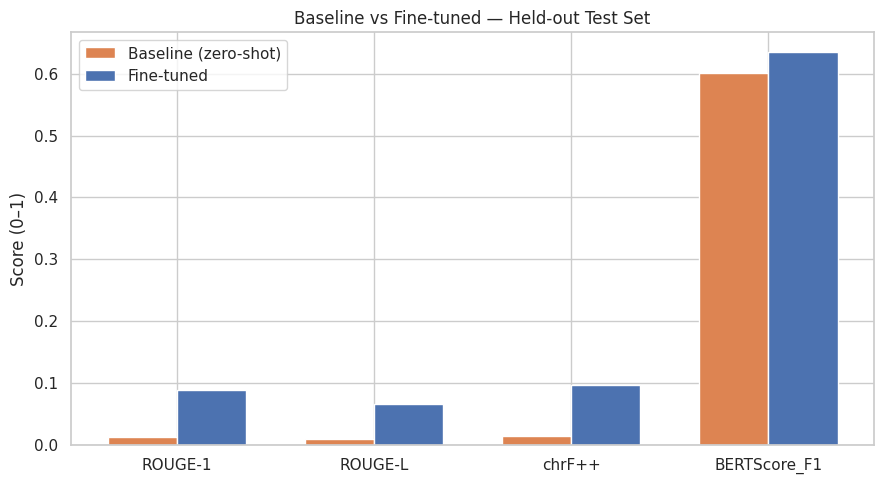

In [22]:
# ── Metric bar chart (baseline vs fine-tuned) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["ROUGE-1", "ROUGE-L", "chrF++", "BERTScore_F1"]
x = np.arange(len(metrics_to_plot)); w = 0.35
ax.bar(x - w/2, [baseline_metrics[m] for m in metrics_to_plot], w, label="Baseline (zero-shot)", color="#DD8452")
ax.bar(x + w/2, [ft_metrics[m] for m in metrics_to_plot], w, label="Fine-tuned", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score (0–1)")
ax.set_title("Baseline vs Fine-tuned — Held-out Test Set")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_baseline_vs_finetuned.png"), dpi=150)
plt.show()


## 13 · Qualitative Error Analysis

In [23]:
N_WORST = 10
worst_idx = np.argsort(ft_per_sample["bertscore_f1"])[:N_WORST]

def _looks_like_refusal(text: str) -> bool:
    t = text.lower()
    return ("don't have that information" in t) or ("contact ewu" in t and len(t.split()) < 25)

error_rows = []
for i in worst_idx:
    error_rows.append({
        "language":      test_langs_eval[i],
        "question":      test_prompts_eval[i],
        "reference":     test_references_eval[i],
        "prediction":    ft_predictions[i],
        "bertscore_f1":  round(ft_per_sample["bertscore_f1"][i], 4),
        "rougeL":        round(ft_per_sample["rougeL"][i], 4),
        "is_refusal":    _looks_like_refusal(ft_predictions[i]),
        "is_domain_hit": ft_per_sample["domain_hit"][i],
    })

error_df = pd.DataFrame(error_rows)
error_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "worst_10_error_cases.csv"), index=False)
print(f"Worst {N_WORST} cases by BERTScore F1 (full text saved to paper_assets/worst_10_error_cases.csv):\n")
print(error_df[["language", "bertscore_f1", "rougeL", "is_refusal", "is_domain_hit"]].to_string(index=False))

refusal_rate = float(np.mean([_looks_like_refusal(p) for p in ft_predictions])) * 100
domain_miss_rate = 100 - ft_metrics["EWU_Domain_Hit_pct"]
print(f"\nOverall refusal rate on test set : {refusal_rate:.1f}%")
print(f"Overall domain-miss rate         : {domain_miss_rate:.1f}%  "
      f"(answers that never mention EWU / East West University)")


Worst 10 cases by BERTScore F1 (full text saved to paper_assets/worst_10_error_cases.csv):

language  bertscore_f1  rougeL  is_refusal  is_domain_hit
banglish        0.5262  0.0000       False          False
 english        0.5383  0.0755       False           True
 english        0.5561  0.1053       False           True
banglish        0.5629  0.0625       False          False
banglish        0.5667  0.0000       False           True
banglish        0.5669  0.0328       False           True
banglish        0.5669  0.0882       False           True
banglish        0.5673  0.0351       False           True
 english        0.5688  0.0784       False           True
banglish        0.5714  0.0000       False          False

Overall refusal rate on test set : 0.0%
Overall domain-miss rate         : 37.2%  (answers that never mention EWU / East West University)


## 13.1 · Human Evaluation Rubric + Inter-Annotator Agreement

**Why this matters:** a 2024 comparison of LLM fine-tuning/evaluation methods on a travel chatbot found
that automatic metrics and even RAGAS-style scores **did not align with human judgment**, and that GPT-4
evaluation aligned best with humans among automatic methods — with the authors concluding *"it is
essential to keep humans in the loop for evaluation"* (Meyer et al., 2024, arXiv:2408.03562). ROUGE and
BERTScore reward surface-level overlap with the reference, not whether the answer is actually correct,
helpful, or safe. Reviewers of a chatbot paper will expect at least a small human evaluation.

This cell exports a **blank annotation sheet** for 2+ human raters (you and a co-author, or two native
Bangla/English speakers) to independently score a random sample of the fine-tuned model's answers on a
5-point Likert scale across four axes, following the standard set used in chatbot evaluation studies:

| Axis | 1 (worst) | 5 (best) |
|---|---|---|
| **Correctness** | Factually wrong / contradicts EWU facts | Fully correct |
| **Helpfulness** | Doesn't address the question at all | Fully answers what was asked |
| **Fluency** | Broken / unreadable in the target language | Native-sounding |
| **Faithfulness** | Invents facts not in training data/KB | Fully grounded, no fabrication |

Once ≥2 annotators fill in their copies, the second cell computes **Krippendorff's alpha** (handles
ordinal Likert data and any number of raters, unlike Cohen's kappa which needs exactly 2) as the
inter-annotator agreement statistic to report alongside mean scores.

In [24]:
N_HUMAN_EVAL_SAMPLES = 50   # small enough for 1-2 people to actually annotate; raise if you have capacity
rng_he = random.Random(SEED)
he_indices = rng_he.sample(range(len(test_prompts_eval)), min(N_HUMAN_EVAL_SAMPLES, len(test_prompts_eval)))

human_eval_template = pd.DataFrame([
    {
        "item_id": i,
        "language": test_langs_eval[i],
        "question": test_prompts_eval[i],
        "reference_answer": test_references_eval[i],
        "model_answer": ft_predictions[i],
        "correctness_1to5": "",
        "helpfulness_1to5": "",
        "fluency_1to5": "",
        "faithfulness_1to5": "",
        "annotator_notes": "",
    }
    for i in he_indices
])

for annotator_n in (1, 2):
    path = os.path.join(PAPER_ASSETS_DIR, f"human_eval_annotator{annotator_n}_BLANK.csv")
    human_eval_template.to_csv(path, index=False)
    print(f"Blank annotation sheet written: {path}")

print(f"\n{len(he_indices)} items sampled for human evaluation.")
print("Have each annotator independently fill in the four *_1to5 columns (no discussion until both are")
print("done), save each as human_eval_annotator{N}_FILLED.csv in paper_assets/, then run the next cell.")


Blank annotation sheet written: /kaggle/working/paper_assets/human_eval_annotator1_BLANK.csv
Blank annotation sheet written: /kaggle/working/paper_assets/human_eval_annotator2_BLANK.csv

50 items sampled for human evaluation.
Have each annotator independently fill in the four *_1to5 columns (no discussion until both are
done), save each as human_eval_annotator{N}_FILLED.csv in paper_assets/, then run the next cell.


### 13.1.1 · Compute Agreement + Summary (run after annotation sheets are filled in)

In [25]:
import krippendorff

filled_paths = sorted(glob.glob(os.path.join(PAPER_ASSETS_DIR, "human_eval_annotator*_FILLED.csv")))

if len(filled_paths) < 2:
    print(f"Found {len(filled_paths)} filled annotation sheet(s) — need at least 2 to compute agreement.")
    print("This cell is a no-op until you've collected ≥2 annotators' filled CSVs; skipping for now.")
    human_eval_summary = {}
else:
    dfs = [pd.read_csv(p) for p in filled_paths]
    axes_cols = ["correctness_1to5", "helpfulness_1to5", "fluency_1to5", "faithfulness_1to5"]

    print(f"Loaded {len(dfs)} annotators' sheets: {[os.path.basename(p) for p in filled_paths]}\n")

    human_eval_summary = {}
    for axis in axes_cols:
        # reliability_data shape: (n_annotators, n_items), ordinal level for Likert scales
        reliability_data = np.array([df[axis].astype(float).values for df in dfs])
        alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="ordinal")
        mean_score = float(np.mean(reliability_data))
        human_eval_summary[axis] = {"mean": round(mean_score, 3), "krippendorff_alpha": round(float(alpha), 3)}
        print(f"  {axis:<20}: mean={mean_score:.2f}/5   Krippendorff's α={alpha:.3f}"
              f"{'  (acceptable agreement)' if alpha >= 0.667 else '  (weak agreement — discuss disagreements)'}")

    with open(os.path.join(PAPER_ASSETS_DIR, "human_eval_summary.json"), "w") as f:
        json.dump(human_eval_summary, f, indent=2)
    print(f"\nSaved → {PAPER_ASSETS_DIR}/human_eval_summary.json")
    print("\nNote for the paper: Krippendorff's α ≥ 0.667 is the conventional threshold for drawing")
    print("conclusions from the data (Krippendorff 2004); below that, report scores with the caveat")
    print("that raters disagreed and discuss representative disagreement cases.")


Found 0 filled annotation sheet(s) — need at least 2 to compute agreement.
This cell is a no-op until you've collected ≥2 annotators' filled CSVs; skipping for now.


## 13.2 · LLM-as-a-Judge (optional — needs an API key, off by default)

Following **Zheng et al. 2023** ("Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena" — GPT-4 as
judge reached >80% agreement with human experts, rivaling inter-human agreement), a strong external LLM
can serve as a scalable proxy for human judgment. This cell implements **pairwise comparison**
(baseline vs. fine-tuned, on the same question) rather than absolute scoring, since Zheng et al. and
follow-up work found pairwise judgments more stable, and it swaps answer order across two calls per item
to cancel out the judge's well-documented **position bias** (its tendency to prefer whichever answer it
sees first).

Disabled by default (`ENABLE_LLM_JUDGE = False`) so the notebook runs end-to-end with zero API cost or
key requirement. Flip it on and set an API key (via Kaggle Secrets, recommended, or paste directly — not
recommended for a shared notebook) to actually run it. Runs on a small subset by default to bound cost.

In [26]:
ENABLE_LLM_JUDGE = False          # set True + provide an API key below to actually run this
LLM_JUDGE_MODEL   = "claude-sonnet-5"      # or an OpenAI model id — swap the call_llm_judge() body to match
N_JUDGE_SAMPLES   = 30                     # keep small: this costs real API calls, 2 per item (order-swapped)

def _get_api_key():
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("ANTHROPIC_API_KEY")
    except Exception:
        return os.environ.get("ANTHROPIC_API_KEY")

JUDGE_PROMPT_TEMPLATE = '''[System]
Please act as an impartial judge and evaluate which of two AI assistant responses better answers the
user's question about East West University (EWU). Judge on correctness, helpfulness, and faithfulness to
what a real EWU assistant should know. Avoid any position, length, or style bias — content quality only.
After your explanation, output your final verdict as exactly one of: "[[A]]", "[[B]]", or "[[TIE]]".

[Question]
{question}

[Response A]
{response_a}

[Response B]
{response_b}'''

def call_llm_judge(question, response_a, response_b):
    import requests
    api_key = _get_api_key()
    if not api_key:
        raise RuntimeError("No API key found — set ANTHROPIC_API_KEY via Kaggle Secrets.")
    resp = requests.post(
        "https://api.anthropic.com/v1/messages",
        headers={"x-api-key": api_key, "anthropic-version": "2023-06-01", "content-type": "application/json"},
        json={"model": LLM_JUDGE_MODEL, "max_tokens": 300,
              "messages": [{"role": "user", "content": JUDGE_PROMPT_TEMPLATE.format(
                  question=question, response_a=response_a, response_b=response_b)}]},
        timeout=30,
    )
    resp.raise_for_status()
    text = resp.json()["content"][0]["text"]
    if "[[A]]" in text: return "A"
    if "[[B]]" in text: return "B"
    return "TIE"

if ENABLE_LLM_JUDGE:
    rng_judge = random.Random(SEED)
    judge_idx = rng_judge.sample(range(len(test_prompts_eval)), min(N_JUDGE_SAMPLES, len(test_prompts_eval)))
    wins_ft, wins_base, ties = 0, 0, 0
    for i in tqdm(judge_idx, desc="LLM-judge pairwise (order-swapped)"):
        q, base_ans, ft_ans = test_prompts_eval[i], baseline_predictions[i], ft_predictions[i]
        v1 = call_llm_judge(q, base_ans, ft_ans)   # A=baseline, B=fine-tuned
        v2 = call_llm_judge(q, ft_ans, base_ans)   # order swapped: A=fine-tuned, B=baseline
        # a "fine-tuned win" requires winning under BOTH orderings (position-bias-robust)
        ft_won   = (v1 == "B") and (v2 == "A")
        base_won = (v1 == "A") and (v2 == "B")
        if ft_won: wins_ft += 1
        elif base_won: wins_base += 1
        else: ties += 1

    n = len(judge_idx)
    llm_judge_summary = {"n": n, "finetuned_win_pct": round(wins_ft / n * 100, 1),
                          "baseline_win_pct": round(wins_base / n * 100, 1),
                          "tie_or_order_inconsistent_pct": round(ties / n * 100, 1)}
    print(json.dumps(llm_judge_summary, indent=2))
    with open(os.path.join(PAPER_ASSETS_DIR, "llm_judge_summary.json"), "w") as f:
        json.dump(llm_judge_summary, f, indent=2)
else:
    print("ENABLE_LLM_JUDGE is False — skipping (this is the default; no API key needed to run the rest of the notebook).")


ENABLE_LLM_JUDGE is False — skipping (this is the default; no API key needed to run the rest of the notebook).


## 14 · Test on 40 Sample Questions (qualitative spot-check, English / Bangla / Banglish)

In [27]:
SAMPLE_QUESTIONS = [
    # English
    "What is the last date to apply for admission at EWU?",
    "Are there any evening programs available at EWU?",
    "What is the medium of instruction at EWU?",
    "Does EWU have an internship or placement program?",
    "How many faculty members does the CSE department have?",
    "What is the grading system used at EWU?",
    "Can I transfer credits from another university to EWU?",
    "Is there a foundation or preparatory course before undergraduate admission?",
    "What research opportunities are available for undergraduate students at EWU?",
    "How do I apply for a leave of absence at EWU?",
    # Bangla
    "EWU-\u09a4\u09c7 \u09ad\u09b0\u09cd\u09a4\u09bf\u09b0 \u099c\u09a8\u09cd\u09af \u0986\u09ac\u09c7\u09a6\u09a8\u09c7\u09b0 \u09b6\u09c7\u09b7 \u09a4\u09be\u09b0\u09bf\u0996 \u0995\u09ac\u09c7?",
    "EWU-\u09a4\u09c7 \u0987\u09ad\u09c7\u09a8\u09bf\u0982 \u09aa\u09cd\u09b0\u09cb\u0997\u09cd\u09b0\u09be\u09ae \u0986\u099b\u09c7 \u0995\u09bf?",
    "EWU-\u09a4\u09c7 \u0995\u09cd\u09b2\u09be\u09b8 \u0995\u09cb\u09a8 \u09ad\u09be\u09b7\u09be\u09df \u09a8\u09c7\u0993\u09df\u09be \u09b9\u09df?",
    "EWU-\u09a4\u09c7 \u0987\u09a8\u09cd\u099f\u09be\u09b0\u09cd\u09a8\u09b6\u09bf\u09aa\u09c7\u09b0 \u09b8\u09c1\u09af\u09cb\u0997 \u0986\u099b\u09c7 \u0995\u09bf?",
    "CSE \u09a1\u09bf\u09aa\u09be\u09b0\u09cd\u099f\u09ae\u09c7\u09a8\u09cd\u099f\u09c7 \u0995\u09a4\u099c\u09a8 \u09b6\u09bf\u0995\u09cd\u09b7\u0995 \u0986\u099b\u09c7\u09a8?",
    "EWU-\u098f\u09b0 \u0997\u09cd\u09b0\u09c7\u09a1\u09bf\u0982 \u09b8\u09bf\u09b8\u09cd\u099f\u09c7\u09ae \u0995\u09c7\u09ae\u09a8?",
    "\u0985\u09a8\u09cd\u09af \u09ac\u09bf\u09b6\u09cd\u09ac\u09ac\u09bf\u09a6\u09cd\u09af\u09be\u09b2\u09df \u09a5\u09c7\u0995\u09c7 EWU-\u09a4\u09c7 \u0995\u09cd\u09b0\u09c7\u09a1\u09bf\u099f \u099f\u09cd\u09b0\u09be\u09a8\u09b8\u09ab\u09be\u09b0 \u0995\u09b0\u09be \u09af\u09be\u09df \u0995\u09bf?",
    "\u09ad\u09b0\u09cd\u09a4\u09bf\u09b0 \u0986\u0997\u09c7 \u0995\u09cb\u09a8\u09cb \u09ab\u09be\u0989\u09a8\u09cd\u09a1\u09c7\u09b6\u09a8 \u0995\u09cb\u09b0\u09cd\u09b8 \u0995\u09b0\u09a4\u09c7 \u09b9\u09df \u0995\u09bf?",
    "\u0986\u09a8\u09cd\u09a1\u09be\u09b0\u0997\u09cd\u09b0\u09cd\u09af\u09be\u09a1 \u09b6\u09bf\u0995\u09cd\u09b7\u09be\u09b0\u09cd\u09a5\u09c0\u09a6\u09c7\u09b0 \u099c\u09a8\u09cd\u09af \u0997\u09ac\u09c7\u09b7\u09a3\u09be\u09b0 \u09b8\u09c1\u09af\u09cb\u0997 \u0986\u099b\u09c7 \u0995\u09bf?",
    "EWU-\u09a4\u09c7 \u099b\u09c1\u099f\u09bf\u09b0 (leave of absence) \u099c\u09a8\u09cd\u09af \u0995\u09c0\u09ad\u09be\u09ac\u09c7 \u0986\u09ac\u09c7\u09a6\u09a8 \u0995\u09b0\u09ac?",
    # Banglish
    "EWU te admission er last date kobe?",
    "EWU te evening program ache ki?",
    "EWU te class kon language e hoy?",
    "EWU te internship er suggestion ache naki?",
    "CSE department e koto jon teacher ache?",
    "EWU er grading system kemon?",
    "Onno university theke EWU te credit transfer kora jay ki?",
    "Admission er age kono foundation course lagbe naki?",
    "Undergrad student der jonno research korar suggestion ache ki?",
    "EWU te leave of absence er jonno kivabe apply korte hobe?",
    # General
    "What is the history and founding year of EWU?",
    "Who is the current Vice Chancellor of EWU?",
    "Does EWU have any international exchange partnerships?",
    "What is EWU's ranking among private universities in Bangladesh?",
    "Does EWU have a career counseling or job placement office?",
    "What safety measures does EWU have on campus?",
    "Does EWU have a mobile app or online student portal?",
    "What health or medical facilities are available on EWU campus?",
    "Does EWU host any annual fests or cultural events?",
    "How can prospective students schedule a campus visit at EWU?",
]

# Language tags matching the block comments above (10 English, 10 Bangla,
# 10 Banglish, 10 General/English) -- hardcoded here since these are
# example questions typed directly into this cell, not loaded from the
# language-labeled dataset folders, so there is no file/folder to derive
# the label from.
SAMPLE_QUESTION_LANGS = (
    ["english"] * 10 +
    ["bangla"] * 10 +
    ["banglish"] * 10 +
    ["english"] * 10   # "General" block is written in English
)
assert len(SAMPLE_QUESTION_LANGS) == len(SAMPLE_QUESTIONS)

print("\n" + "="*70)
print(" 40 SAMPLE QUESTION TEST (fine-tuned model)")
print("="*70)

sample_results = []
for i, (q, lang) in enumerate(zip(SAMPLE_QUESTIONS, SAMPLE_QUESTION_LANGS), 1):
    resp = generate_response(q)
    sample_results.append({"question": q, "answer": resp, "language": lang})
    lang_tag = lang.upper()
    print(f"\n[{i:02d}] [{lang_tag}] {q}")
    print(f"  \u2192 {resp[:300]}{'...' if len(resp) > 300 else ''}")

with open(os.path.join(PAPER_ASSETS_DIR, 'sample_qa.json'), 'w', encoding='utf-8') as f:
    json.dump(sample_results, f, ensure_ascii=False, indent=2)
print("\n[OK] Sample Q&A saved to paper_assets/sample_qa.json")



 40 SAMPLE QUESTION TEST (fine-tuned model)

[01] [ENGLISH] What is the last date to apply for admission at EWU?
  → The last date to apply for admission is August 11, 2026.

[02] [ENGLISH] Are there any evening programs available at EWU?
  → Yes, the Institute of Education and Research (IER) offers an Evening Program for the B.Ed. degree[cite: 10].

[03] [ENGLISH] What is the medium of instruction at EWU?
  → The medium of instruction is English.

[04] [ENGLISH] Does EWU have an internship or placement program?
  → Yes, EWU offers a Career Counseling Center (CCC) which facilitates internships and placements.

[05] [ENGLISH] How many faculty members does the CSE department have?
  → The CSE department has 17 faculty members.

[06] [ENGLISH] What is the grading system used at EWU?
  → The grading system used at East West University is a numeric scale with letter grades.

[07] [ENGLISH] Can I transfer credits from another university to EWU?
  → Yes, students can apply to transfer credit

## 15 · Save Adapter & Export ZIP

In [28]:
# ── Save LoRA adapter ─────────────────────────────────────────────────────────
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "adapter")
os.makedirs(ADAPTER_DIR, exist_ok=True)

model.save_pretrained(ADAPTER_DIR)           # adapter_config.json + adapter_model.safetensors
tokenizer.save_pretrained(ADAPTER_DIR)       # tokenizer.json + tokenizer_config.json

# ── chat_template.jinja ───────────────────────────────────────────────────────
chat_template = '''{% for message in messages %}
{%- if message['role'] == 'system' %}<|im_start|>system
{{ message['content'] }}<|im_end|>
{% elif message['role'] == 'user' %}<|im_start|>user
{{ message['content'] }}<|im_end|>
{% elif message['role'] == 'assistant' %}<|im_start|>assistant
{{ message['content'] }}<|im_end|>
{% endif %}
{% endfor %}
{%- if add_generation_prompt %}<|im_start|>assistant
{% endif %}'''
with open(os.path.join(ADAPTER_DIR, 'chat_template.jinja'), 'w') as f:
    f.write(chat_template)

# ── eval_metrics.json (test-set based, includes baseline for comparison) ─────
eval_output = {
    "model": MODEL_ID,
    "trained_at": datetime.now().isoformat(),
    "epochs": NUM_EPOCHS,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "test_samples_total": len(test_idx),
    "test_samples_evaluated": len(eval_test_idx),
    "baseline_metrics": baseline_metrics,
    "finetuned_metrics": ft_metrics,
    "finetuned_metrics_by_language": ft_metrics_by_lang,
    "significance_baseline_vs_finetuned": comparison_rows,
}
with open(os.path.join(ADAPTER_DIR, 'eval_metrics.json'), 'w') as f:
    json.dump(eval_output, f, indent=2)
shutil.copy(os.path.join(ADAPTER_DIR, 'eval_metrics.json'), os.path.join(PAPER_ASSETS_DIR, 'eval_metrics.json'))

# ── README.md ─────────────────────────────────────────────────────────────────
readme = f'''# EWU Chatbot — Fine-tuned Qwen2.5-7B-Instruct

## Model Info
- **Base model**: `{MODEL_ID}`
- **Method**: QLoRA (4-bit NF4, r=16, alpha=32)
- **Trained on**: Kaggle T4 GPU
- **Epochs**: {NUM_EPOCHS}
- **Languages**: English · বাংলা · Banglish
- **Date**: {datetime.now().strftime('%Y-%m-%d')}

## Evaluation (held-out TEST set, n={len(eval_test_idx)})
| Metric | Baseline (zero-shot) | Fine-tuned | p (bootstrap) |
|---|---|---|---|
| ROUGE-1 | {baseline_metrics['ROUGE-1']} | {ft_metrics['ROUGE-1']} | — |
| ROUGE-L | {baseline_metrics['ROUGE-L']} | {ft_metrics['ROUGE-L']} | — |
| BERTScore F1 | {baseline_metrics['BERTScore_F1']} | {ft_metrics['BERTScore_F1']} | — |
| EWU Domain Hit % | {baseline_metrics['EWU_Domain_Hit_pct']} | {ft_metrics['EWU_Domain_Hit_pct']} | — |

Full per-metric significance tests: see `paper_assets/baseline_vs_finetuned_significance.csv`.

## Usage
```python
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

base_model = AutoModelForCausalLM.from_pretrained("{MODEL_ID}", torch_dtype=torch.float16, device_map="auto")
tokenizer  = AutoTokenizer.from_pretrained("./adapter")
model      = PeftModel.from_pretrained(base_model, "./adapter")
model.eval()
```

## Files
- `adapter_config.json` — LoRA config
- `adapter_model.safetensors` — LoRA weights
- `chat_template.jinja` — Qwen2 chat template
- `eval_metrics.json` — training + evaluation results (baseline + fine-tuned + significance)
- `tokenizer.json` / `tokenizer_config.json` — tokenizer files
'''
with open(os.path.join(ADAPTER_DIR, 'README.md'), 'w', encoding='utf-8') as f:
    f.write(readme)

print("\nAdapter files saved:")
for fp in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, fp))
    print(f"  {fp:<45s}  {size/1e6:>8.2f} MB")



Adapter files saved:
  README.md                                          0.00 MB
  adapter_config.json                                0.00 MB
  adapter_model.safetensors                        161.53 MB
  added_tokens.json                                  0.00 MB
  chat_template.jinja                                0.00 MB
  eval_metrics.json                                  0.00 MB
  merges.txt                                         1.67 MB
  special_tokens_map.json                            0.00 MB
  tokenizer.json                                    11.42 MB
  tokenizer_config.json                              0.01 MB
  vocab.json                                         2.78 MB


In [29]:
# ── Create ZIP ────────────────────────────────────────────────────────────────
print(f"\nCreating ZIP: {ZIP_NAME} ...")
with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in os.listdir(ADAPTER_DIR):
        full_path = os.path.join(ADAPTER_DIR, fp)
        zf.write(full_path, arcname=fp)
        print(f"  + {fp}")

zip_size = os.path.getsize(ZIP_NAME) / 1e6
print(f"\n✅ ZIP created: {ZIP_NAME}  ({zip_size:.1f} MB)")
print("   Download it from  File → Output  in Kaggle.")



Creating ZIP: /kaggle/working/ewu_chatbot_finetuned.zip ...
  + merges.txt
  + tokenizer_config.json
  + README.md
  + vocab.json
  + adapter_config.json
  + added_tokens.json
  + adapter_model.safetensors
  + tokenizer.json
  + special_tokens_map.json
  + chat_template.jinja
  + eval_metrics.json

✅ ZIP created: /kaggle/working/ewu_chatbot_finetuned.zip  (153.8 MB)
   Download it from  File → Output  in Kaggle.


## 16 · Fine-Tuning Summary

In [30]:
print("\n" + "╔" + "═"*66 + "╗")
print("║" + " EWU CHATBOT FINE-TUNING — TEST-SET SUMMARY ".center(66) + "║")
print("╠" + "═"*66 + "╣")
print(f"║  Base model   : {MODEL_ID:<48s} ║")
print(f"║  Adapter      : QLoRA r=16, alpha=32                              ║")
print(f"║  Epochs       : {NUM_EPOCHS:<48d} ║")
print(f"║  Train pairs  : {len(train_dataset):<48d} ║")
print(f"║  Val pairs    : {len(val_dataset):<48d} ║")
print(f"║  Test pairs   : {len(test_idx):<48d} ║")
print("╠" + "═"*66 + "╣")
for k in ft_metrics:
    b, f_ = baseline_metrics[k], ft_metrics[k]
    print(f"║  {k:<22}: base={str(b):<12s} → ft={str(f_):<12s}          ║")
print("╠" + "═"*66 + "╣")
print(f"║  Output ZIP   : ewu_chatbot_finetuned.zip                         ║")
print(f"║  Paper assets : {PAPER_ASSETS_DIR:<48s} ║")
print("╚" + "═"*66 + "╝")



╔══════════════════════════════════════════════════════════════════╗
║            EWU CHATBOT FINE-TUNING — TEST-SET SUMMARY            ║
╠══════════════════════════════════════════════════════════════════╣
║  Base model   : Qwen/Qwen2.5-7B-Instruct                         ║
║  Adapter      : QLoRA r=16, alpha=32                              ║
║  Epochs       : 10                                               ║
║  Train pairs  : 8703                                             ║
║  Val pairs    : 1087                                             ║
║  Test pairs   : 890                                              ║
╠══════════════════════════════════════════════════════════════════╣
║  ROUGE-1               : base=0.0115       → ft=0.0888                ║
║  ROUGE-2               : base=0.0009       → ft=0.0171                ║
║  ROUGE-L               : base=0.0089       → ft=0.0654                ║
║  BERTScore_F1          : base=0.6015       → ft=0.6354                ║
║  chrF++   

## 16.1 · Session Handoff (save state for Notebook B)
Splits the pipeline across two Kaggle sessions to avoid the 12-hour timeout. This cell saves everything Notebook B needs (eval set, baseline + fine-tuned predictions/metrics, shared config) to disk. Run this, then move to Notebook B in a new session.

In [31]:
# ══════════════════════════════════════════════════════════════════════════
# SESSION HANDOFF — save everything Notebook B (RAG/cache/ablation/judge)
# needs, so B can start a fresh Kaggle session instead of re-running
# training/baseline/fine-tuned eval (which is what timed out before).
# ══════════════════════════════════════════════════════════════════════════
import pickle, json, os

HANDOFF_DIR = os.path.join(OUTPUT_DIR, "handoff_to_notebook_b")
os.makedirs(HANDOFF_DIR, exist_ok=True)

handoff_payload = {
    # eval set (§8.1, the 333-item category-stratified set)
    "test_prompts_eval":    test_prompts_eval,
    "test_references_eval": test_references_eval,
    "test_langs_eval":      test_langs_eval,
    "eval_test_idx":        eval_test_idx,

    # baseline results (§9)
    "baseline_predictions": baseline_predictions,
    "baseline_metrics":     baseline_metrics,
    "baseline_per_sample":  baseline_per_sample,
    "baseline_by_lang":     baseline_by_lang,

    # fine-tuned results (§11/12)
    "ft_predictions":  ft_predictions,
    "ft_metrics":      ft_metrics,
    "ft_per_sample":   ft_per_sample,
    "ft_metrics_by_lang": ft_metrics_by_lang,

    # config constants §17+ reuse
    "SYSTEM_PROMPT": SYSTEM_PROMPT,
    "SEED": SEED,
    "MODEL_ID": MODEL_ID,
    "MAX_SEQ_LEN": MAX_SEQ_LEN,
    "N_BOOTSTRAP": N_BOOTSTRAP,
    "BOOTSTRAP_CI": BOOTSTRAP_CI,
    "WEAK_LABEL_THRESHOLD": WEAK_LABEL_THRESHOLD,
    "CACHE_THRESHOLD_SWEEP": CACHE_THRESHOLD_SWEEP,
    "CHUNK_SIZE": CHUNK_SIZE,
    "CHUNK_OVERLAP": CHUNK_OVERLAP,
    "TOP_K_DENSE": TOP_K_DENSE,
    "TOP_K_SPARSE": TOP_K_SPARSE,
    "TOP_K_FINAL": TOP_K_FINAL,

    # where the trained adapter ended up (Notebook B reloads the model + this adapter)
    "ADAPTER_DIR": ADAPTER_DIR,
}

handoff_path = os.path.join(HANDOFF_DIR, "handoff.pkl")
with open(handoff_path, "wb") as f:
    pickle.dump(handoff_payload, f)

print(f"✅ Handoff saved: {handoff_path}")
print(f"   Contains: eval set ({len(test_prompts_eval)} items), baseline + fine-tuned")
print(f"   predictions/metrics, and shared config constants.")
print()
print("NEXT STEPS:")
print("  1. In Kaggle: File → Output, download/keep this notebook's output folder")
print(f"     (or add it as a Kaggle Dataset) so `{HANDOFF_DIR}` is mountable.")
print("  2. Also keep the adapter ZIP / ADAPTER_DIR from §15, and the LoRA")
print("     checkpoint dataset path you used in cell 33 (ADAPTER_CHECKPOINT_DIR) —")
print("     Notebook B reloads the base model + this adapter fresh.")
print("  3. Open Notebook B, set HANDOFF_PATH and ADAPTER_CHECKPOINT_DIR at the top,")
print("     and run from there — it picks up exactly where this notebook left off.")

✅ Handoff saved: /kaggle/working/ewu_qwen_lora/handoff_to_notebook_b/handoff.pkl
   Contains: eval set (333 items), baseline + fine-tuned
   predictions/metrics, and shared config constants.

NEXT STEPS:
  1. In Kaggle: File → Output, download/keep this notebook's output folder
     (or add it as a Kaggle Dataset) so `/kaggle/working/ewu_qwen_lora/handoff_to_notebook_b` is mountable.
  2. Also keep the adapter ZIP / ADAPTER_DIR from §15, and the LoRA
     checkpoint dataset path you used in cell 33 (ADAPTER_CHECKPOINT_DIR) —
     Notebook B reloads the base model + this adapter fresh.
  3. Open Notebook B, set HANDOFF_PATH and ADAPTER_CHECKPOINT_DIR at the top,
     and run from there — it picks up exactly where this notebook left off.
